# Google Play Store Analysis Project

### Importing all the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing the dataset

In [2]:
df = pd.read_csv("../data/googleplaystore.csv")

#### Checking number of rows and columns

In [3]:
print("Number of rows = ",df.shape[0])
print("Number of columns = ",df.shape[1])

Number of rows =  10841
Number of columns =  13


#### Removing duplicate rows based on Primary column

In [4]:
df = df.drop_duplicates(subset = 'App')
print("Number of rows in dataset now = ",df.shape[0])

Number of rows in dataset now =  9660


#### There are 13 columns in the dataset. What does each column represent?

In [5]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


#### Understanding the Dataset

From inspecting the column names and a few sample rows, the dataset appears to contain information about applications available on the Google Play Store.

| Column | Description |
|--------|-------------|
| App | Name of the application |
| Category | Category of the application |
| Rating | Average user rating |
| Reviews | Total number of user reviews |
| Size | Size of the application |
| Installs | Approximate number of installs |
| Type | Free or Paid |
| Price | Price of the application |
| Content Rating | Intended audience |
| Genres | App genre |
| Last Updated | Date the app was last updated |
| Current Ver | Current version |
| Android Ver | Minimum Android version required |

#### Actual-Value Converter Function

In [6]:
def actual_value(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().upper()
    if '+' in x or ',' in x or '$' in x:
        x = x.replace('+','').replace(',','').replace('$','')
    # replace M-millions , L-lakhs and K-thousands
    try:
        if 'M' in x:
            return float(x.replace('M','')) * 1000000
        if 'L' in x:
            return float(x.replace('L','')) * 100000
        if 'K' in x:
            return float(x.replace('K','')) * 1000
        return float(x)
    except ValueError:
        return pd.NA

#### Actual-Size (MB) Converter Function

In [7]:
def convert_size(x):
    if pd.isna(x):
        return np.nan
    if x == "Varies with device":
        return np.nan

    x = str(x).strip()

    if x.endswith("M"):
        return float(x[:-1])

    elif x.endswith("k"):
        return float(x[:-1]) / 1024

    return np.nan

### Changing the data types of columns accordingly

#### Changing Categorical types
* Since the columns Category, Type, Content Rating and Genres are representing categorical data, we change them to 'category' data type.

In [8]:
df['Category'] = df['Category'].astype('category')
df['Type'] = df['Type'].astype('category')
df['Content Rating'] = df['Content Rating'].astype('category')
df['Genres'] = df['Genres'].astype('category')

#### Changing Float types
The columns Reviews, Size, Rating and Price are numerical columns. But they are filled with extensions like 'M', 'K', etc representing 'Millions', 'Thousands',etc. So before converting these columns' data types from string to float, we call the actual_value() function to convert them into pure numerical strings.

In [9]:
df['Reviews'] =df['Reviews'].apply(actual_value)
df['Reviews'] = df['Reviews'].astype('Float64')

df['Size'] =df['Size'].apply(convert_size)
df['Size'] = df['Size'].astype('Float64')

df['Rating'] =df['Rating'].apply(actual_value)
df['Rating'] = df['Rating'].astype('Float64')

df['Price'] =df['Price'].apply(actual_value)
df['Price'] = df['Price'].astype('Float64')

#### Changing Integer types
Similar to other numerical columns, Installs column is also filled with a lot of non-numeric values like '1000+', '50M', etc. So have to apply the same rules as we did for float type columns.

In [10]:
df['Installs'] =df['Installs'].apply(actual_value)
df['Installs'] = df['Installs'].astype('Int64')

#### Changing Date & String types
* Last Updated column has full month names and date seperated by commas. Best way to format this kind of data into date & time columns is by using pandas 'to_datetime()' function.
* As Android Version column holds the minimum version required for the app, it will be having string values like '1.20 and above', '2.13 minimum', etc. As the intentions of the column representing minimum versions is clear, we can only store the exact version values in the form of strings.

In [11]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'],errors='coerce').dt.strftime('%d-%m-%Y')
df['Last Updated'] = pd.to_datetime(df['Last Updated'],format='%d-%m-%Y')

df['Android Ver'] = df['Android Ver'].str.strip().replace('and up','',regex = False)

### Data Types after modifications

In [12]:
df.dtypes

App                          str
Category                category
Rating                   Float64
Reviews                  Float64
Size                     Float64
Installs                   Int64
Type                    category
Price                    Float64
Content Rating          category
Genres                  category
Last Updated      datetime64[us]
Current Ver                  str
Android Ver                  str
dtype: object

#### Fixing invalid values

In [13]:
df['Current Ver'] = df['Current Ver'].replace('Varies with device',pd.NA)

In [14]:
df['Android Ver'] = df['Android Ver'].str.replace('and up','')
df['Android Ver'] = df['Android Ver'].replace('Varies with device',pd.NA).replace('nan',pd.NA)

#### Checking for columns with minimum missing values, which can be filled manually.

In [15]:
Columns = df.columns[(df.isna().sum() <= 10) & (df.isna().sum() != 0)].tolist()
for column in Columns:
    print(f"{column:<20}{df[column].isna().sum()}")

Installs            1
Type                1
Price               1
Content Rating      1
Last Updated        1


#### fixing invalid values

Type column is representing whether the app is free or paid. So we fill missing values based on the price of the app. If the price > 0 , then the app must of paid type. else, it must be of free type.

In [16]:
df.loc[(df['Type'].isna()) & (df['Price'] > 0), 'Type'] = 'Paid'
df.loc[(df['Type'].isna()) & (df['Price'] == 0), 'Type'] = 'Free'
df.loc[df['Type'] == '0','Type'] = 'Free'

There are invalid ratings like 19.5, -1.0, etc. We know that the rating of apps in playstore lies from 0 to 5 stars. So we drag negative reviews to zero and reviews > 5 to 5.

In [17]:
df.loc[df['Rating'] < 0 ,'Rating'] = 0
df.loc[df['Rating'] > 5 ,'Rating'] = 5

The price has to be a numeric value. If it is not mentioned, then the optimal assumption is it is free. So we will fill them with 0.

In [18]:
df.loc[df['Price'].isna() ,'Price'] = 0

Similarly, As Content-Rating column already had 'Unrated' value, we will fill missing values with it.

In [19]:
df.loc[df['Content Rating'].isna() ,'Content Rating'] = 'Unrated'

Not mentioning of number of installs is a sign that none of the people installed it. So it must be filled with zeroes.

In [20]:
df.loc[df['Installs'].isna() ,'Installs'] = 0

There is another column 'Last Updated' with missing values, holding the last date when the app was updated. As we don't have the data about the first releases of the apps either, we can leave the column as it is.

In [21]:
df['Category'] = df['Category'].cat.remove_unused_categories()
df['Type'] = df['Type'].cat.remove_unused_categories()
df['Content Rating'] = df['Content Rating'].cat.remove_unused_categories()
df['Genres'] = df['Genres'].cat.remove_unused_categories()

#### Missing values of each column

In [22]:
for column in df.columns:
    print(f"{column:<20}{df[column].isna().sum()}")

App                 0
Category            0
Rating              1463
Reviews             0
Size                1228
Installs            0
Type                0
Price               0
Content Rating      0
Genres              0
Last Updated        1
Current Ver         1063
Android Ver         993


### Data after cleaning

In [23]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,NaN,4.2
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4


#### There is an invalid category '1.9'

In [24]:
df['Category'].unique()

['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY', 'BOOKS_AND_REFERENCE', 'BUSINESS', ..., 'WEATHER', 'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION', '1.9']
Length: 34
Categories (34, str): ['1.9', 'ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY', ..., 'TOOLS', 'TRAVEL_AND_LOCAL', 'VIDEO_PLAYERS', 'WEATHER']

#### It seems like the values are shifted by one left, due to a missing category, which also lead to NaT

In [25]:
df[df['Category'] == '1.9']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,5.0,3000000.0,<NA>,0,Free,0.0,Unrated,"February 11, 2018",NaT,4.0 and up,NaN


#### So, dropping that row would be a better choice.

In [26]:
df = df[df['Category'] != '1.9']

## Exploratory Data Analysis

'ggplot' for making graphs more expressive

In [27]:
plt.style.use('ggplot')

### Dominating App Categories of the play store :

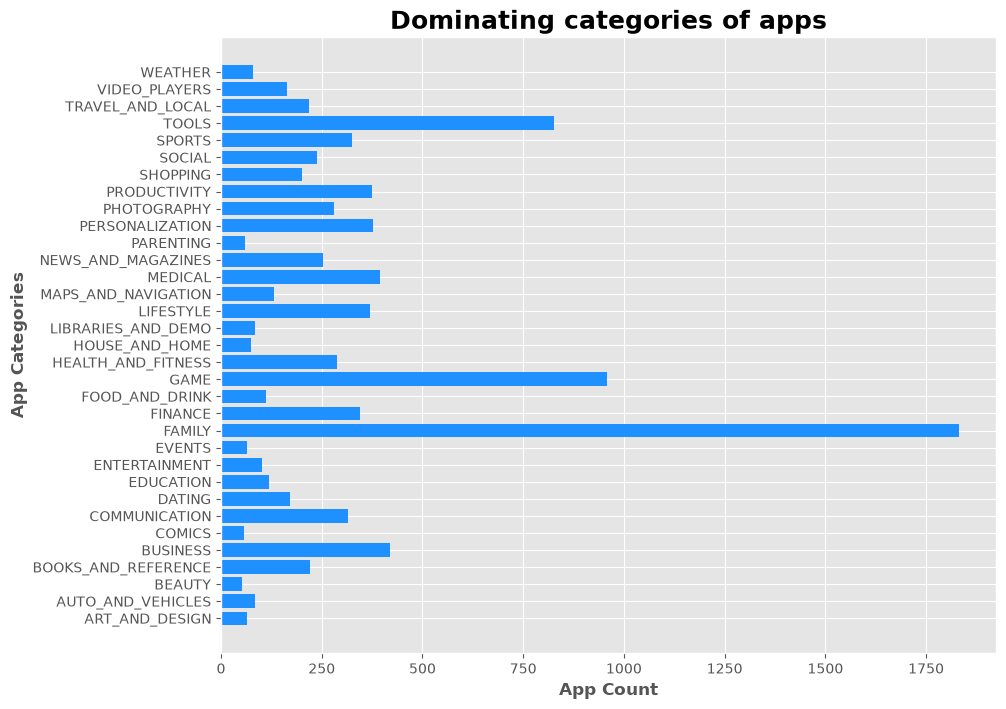

In [28]:
gb_category = df.groupby('Category',dropna = False)
AppCounts = gb_category['App'].count()

plt.figure(figsize = (10,8))
plt.barh(AppCounts.index,AppCounts.values,color = 'dodgerblue')
plt.xlabel('App Count', fontweight = 'bold')
plt.ylabel('App Categories',fontweight = 'bold')
plt.title('Dominating categories of apps',fontsize=18,
          fontweight='bold',color='black')
plt.show()

#### It can be clearly observed that there are more number of apps under 'Family' category followed by 'Game'.

---

### Categories with highest average ratings :

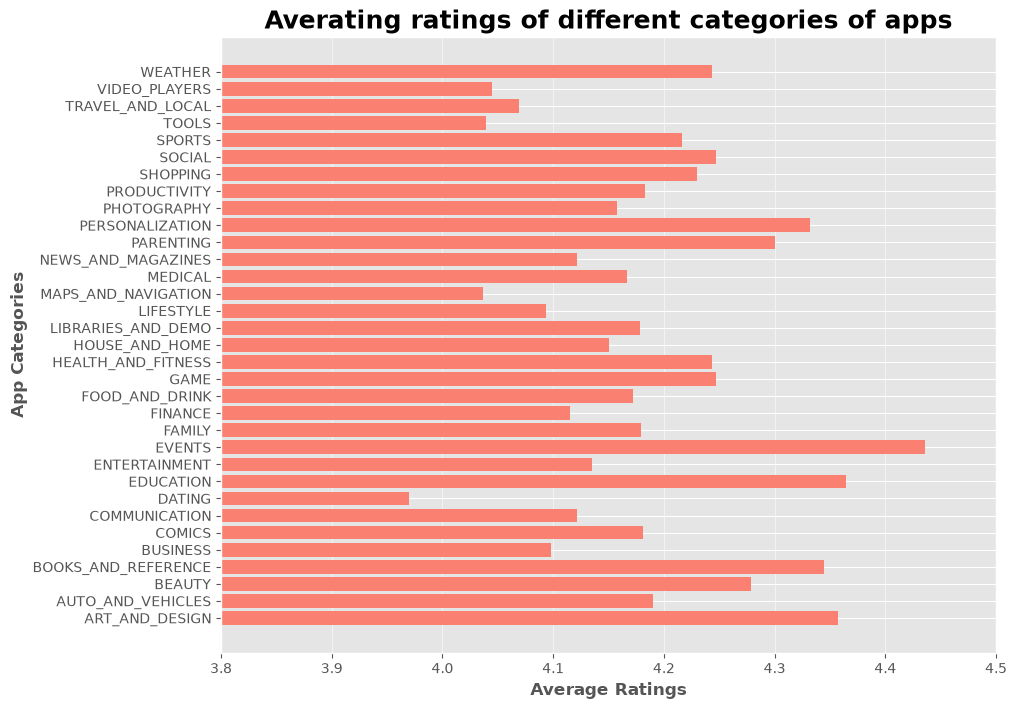

In [29]:
rating_avg = gb_category['Rating'].mean()

plt.figure(figsize = (10,8))
plt.barh(rating_avg.index,rating_avg.values,color = 'salmon')
plt.xlim(3.8,4.5)
plt.grid(axis='x',alpha =0.5)
plt.xlabel('Average Ratings', fontweight = 'bold')
plt.ylabel('App Categories',fontweight = 'bold')
plt.title('Averating ratings of different categories of apps',fontsize=18,
          fontweight='bold',color='black')
plt.show()

#### Apps under category 'Events' , 'Education', 'Art and Design' are the highest rated on average
---

### Categories with more number of installs :

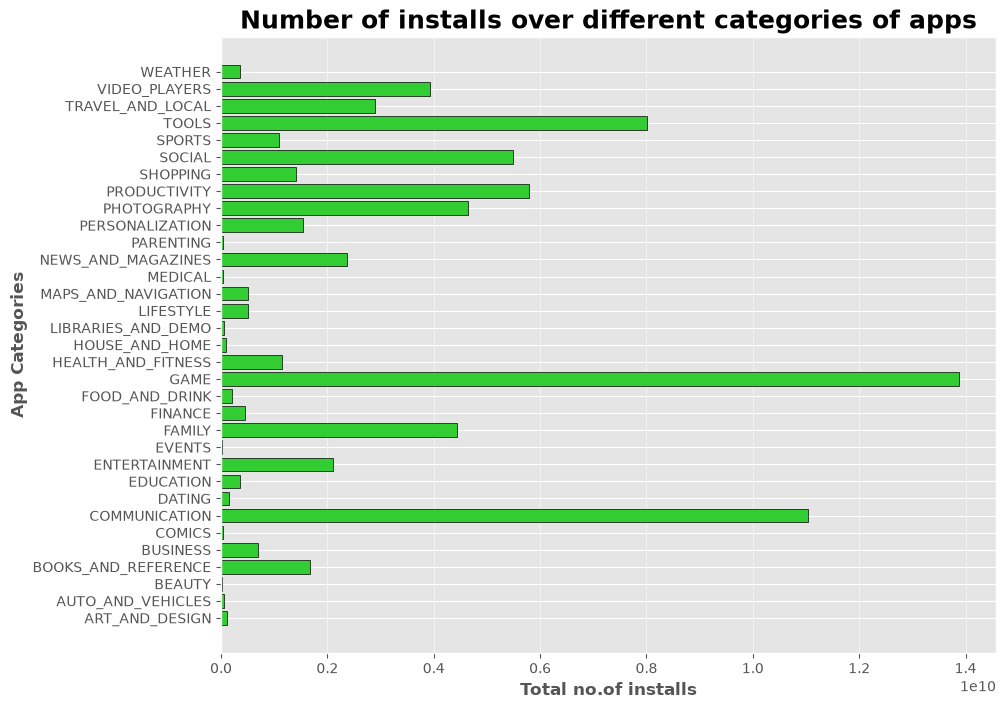

In [30]:
installs_count = gb_category['Installs'].sum()
plt.figure(figsize = (10,8))
plt.barh(installs_count.index,installs_count.values,color = 'limegreen',edgecolor = 'black')
plt.grid(axis='x',alpha =0.5)
plt.xlabel('Total no.of installs', fontweight = 'bold')
plt.ylabel('App Categories',fontweight = 'bold')
plt.title('Number of installs over different categories of apps',fontsize=18,
          fontweight='bold',color='black')
plt.show()

#### Inspite of average ratings, 'Game' is the most downloaded app category followed by 'Communication'.

---

### Rating distribution of apps across play store :

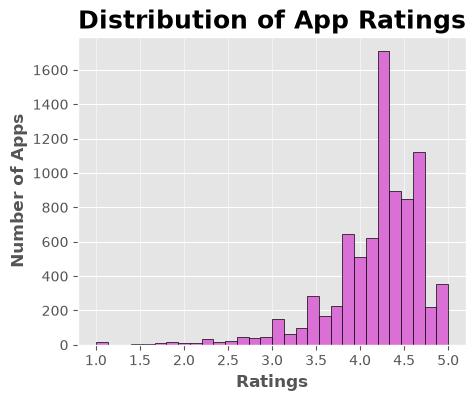

In [31]:
plt.figure(figsize = (5,4))
plt.hist(df['Rating'],bins = 30,color = 'orchid',edgecolor = 'black')
plt.grid(axis='x',alpha =0.5)
plt.xlabel('Ratings', fontweight = 'bold')
plt.ylabel('Number of Apps',fontweight = 'bold')
plt.title('Distribution of App Ratings',fontsize=18,
          fontweight='bold',color='black')
plt.show()

#### Most of the apps in google play store are rated in range of 3.5 - 4.5, which explains the popularity of the platform.

---

### Whether having more reviews result in higher ratings :

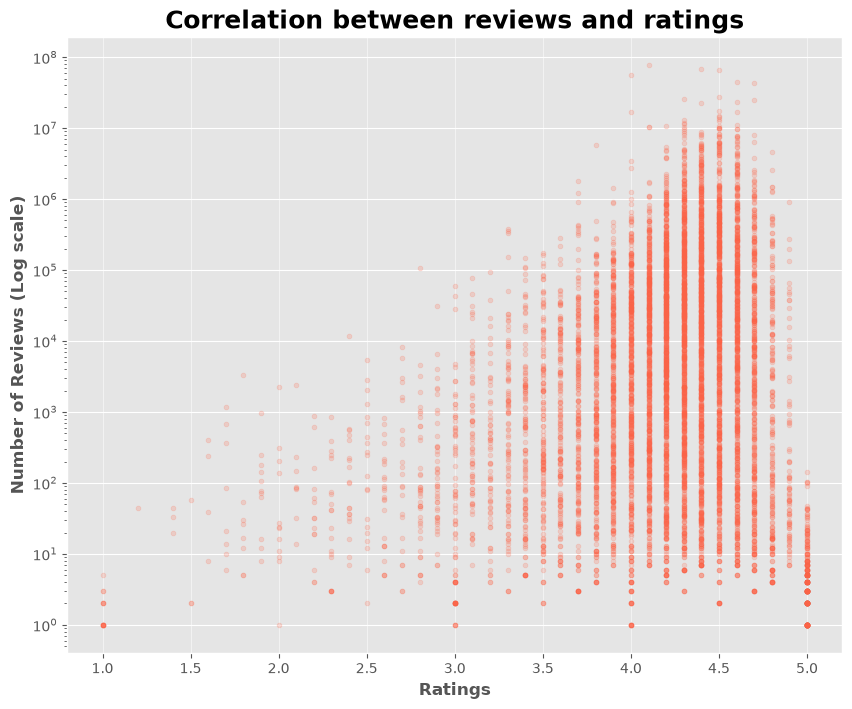

Pearson correlation coefficient between Ratings and Reviews is = 0.0551


In [32]:
plt.figure(figsize = (10,8))
plt.scatter(df['Rating'],df['Reviews'],color = 'tomato',alpha = 0.2, s = 12)
plt.grid(axis='x',alpha =0.5)
plt.yscale('log')
plt.xlabel('Ratings', fontweight = 'bold')
plt.ylabel('Number of Reviews (Log scale)',fontweight = 'bold')
plt.title('Correlation between reviews and ratings',fontsize=18,
          fontweight='bold',color='black')
plt.show()
print(f"Pearson correlation coefficient between Ratings and Reviews is = {df['Rating'].corr(df['Reviews']):.4f}")

#### From the graph, it is true that more number of reviews result in higher ratings. 
* But number of reviews and ratings are not perfectly correlated. We can look at the Pearson correlation coefficient between them is ~ 0.05 which is a weak positive correlation.

---

### Do high rated apps receive more installs?

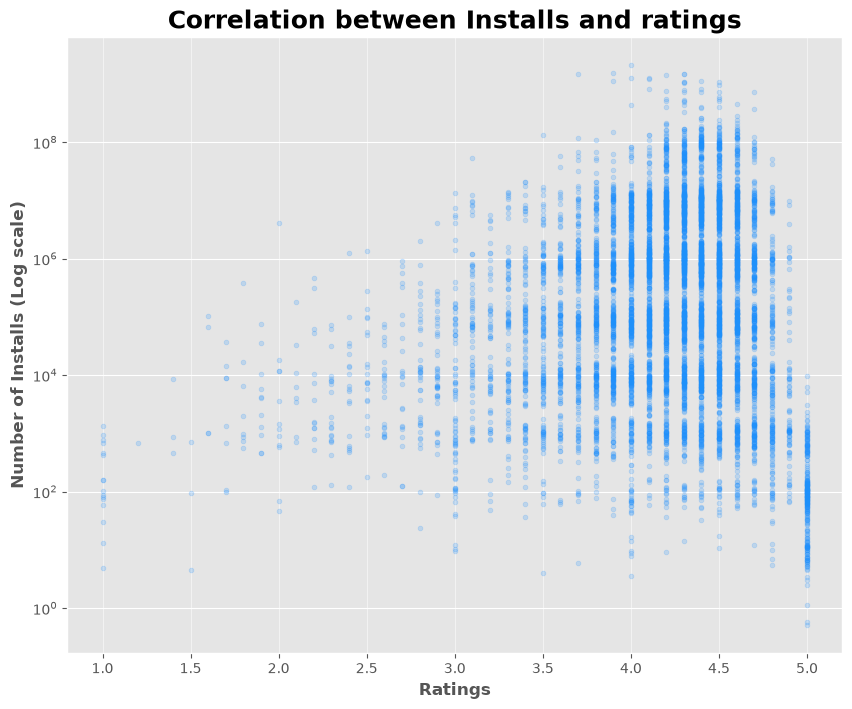

In [33]:
plt.figure(figsize = (10,8))
# jitter for installs, because they were rounded off with records like 1000+, 1M+, etc
installs = df['Installs'] * np.exp(np.random.normal(0, 0.4, len(df)))
plt.scatter(df['Rating'],installs,color = 'dodgerblue',alpha = 0.2, s = 12)
plt.grid(axis='x',alpha =0.5)
plt.yscale('log')
plt.xlabel('Ratings', fontweight = 'bold')
plt.ylabel('Number of Installs (Log scale)',fontweight = 'bold')
plt.title('Correlation between Installs and ratings',fontsize=18,
          fontweight='bold',color='black')
plt.show()

* From the plot, we can clearly see that the number of installs increases over ratings. It is a positive correlation. So, we can conclude that people consider ratings while downloading apps.

---

### Ratio of Free and Paid apps in play store :

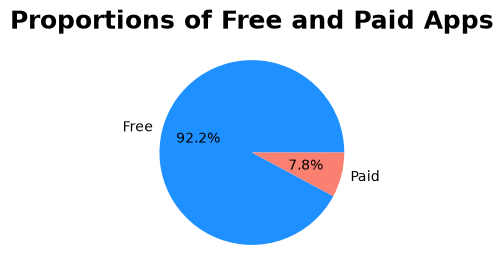

In [34]:
plt.figure(figsize = (3,3))
type_frequencies = df['Type'].dropna().value_counts()
plt.pie(type_frequencies,
        labels = type_frequencies.index,
        colors = ['dodgerblue', 'salmon'],
       textprops={'color':'black'},
       autopct='%1.1f%%')
plt.title('Proportions of Free and Paid Apps',fontsize=18,
          fontweight='bold',color='black')
plt.show()

#### More than 92 % of the apps in play store are free. There are very few apps comparatively need to paid.

---

### Do paid apps receive better rating than free apps ?

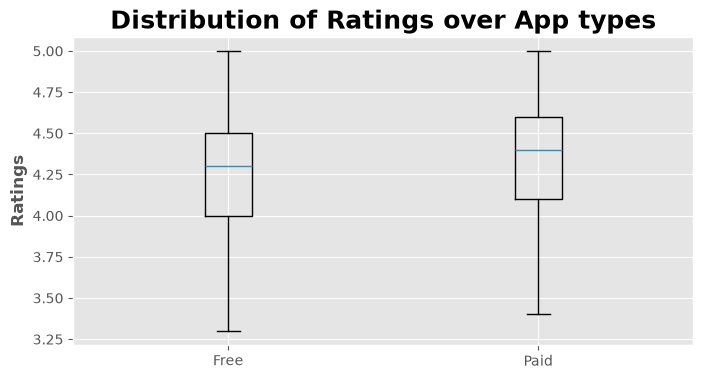

In [35]:
plt.figure(figsize = (8,4))
plt.boxplot([df[df['Type'] == 'Free']['Rating'].dropna(),
            df[df['Type'] == 'Paid']['Rating'].dropna()],
            tick_labels = ['Free','Paid'],
           showfliers=False)
plt.ylabel('Ratings',fontweight = 'bold')
plt.title('Distribution of Ratings over App types',fontsize=18,
          fontweight='bold',color='black')
plt.show()

* Paid apps have a slightly higher median rating than free apps. The central 50% of paid app ratings also lies at slightly higher values. However, the two distributions overlap substantially, suggesting that while paid apps tend to receive marginally better ratings, the difference is not large.

---

### Effect of Price of the apps on their download rates :

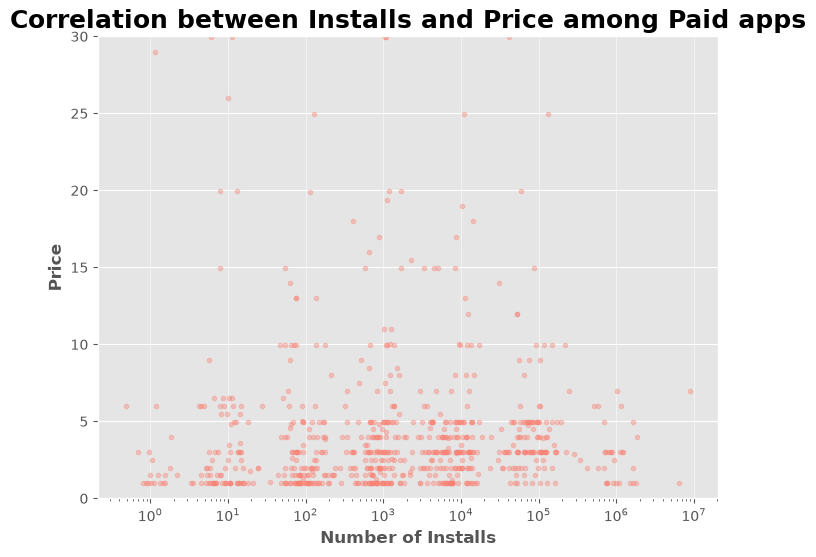

Pearson Coefficient is -0.0215


In [36]:
plt.figure(figsize = (8,6))
paid_apps = df[df['Type'] == 'Paid']
# jitter for installs, because they were rounded off with records like 1000+, 1M+, etc
paid_installs = paid_apps['Installs'] * np.exp(np.random.normal(0, 0.4, len(paid_apps)))
plt.scatter(paid_installs,paid_apps['Price'],color = 'salmon',alpha = 0.4, s = 12)
plt.grid(axis='x',alpha =0.5)
plt.xscale('log')
plt.ylim(0,30)
plt.xlabel('Number of Installs', fontweight = 'bold')
plt.ylabel('Price',fontweight = 'bold')
plt.title('Correlation between Installs and Price among Paid apps',fontsize=18,
          fontweight='bold',color='black')
plt.show()

print(f"Pearson Coefficient is {paid_apps['Price'].corr(paid_apps['Installs']):.4f}")

* Most of the paid apps cost under 20$. Although the graph is overlapping, we can find a little negative correlation of ~ 0.02 indicating that low-price apps are installed more compared to high-price apps

---

### App Characteristics :

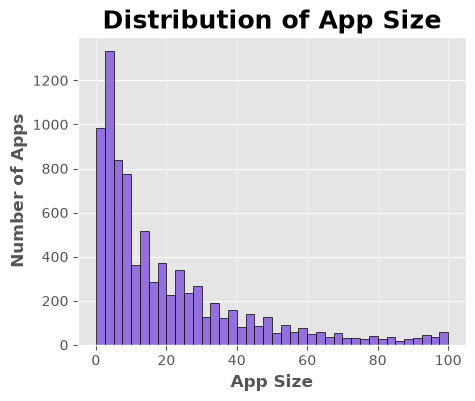

In [37]:
plt.figure(figsize = (5,4))
plt.hist(df['Size'],bins = 40,color = 'mediumpurple',edgecolor = 'black')
plt.grid(axis='x',alpha =0.5)
plt.xlabel('App Size', fontweight = 'bold')
plt.ylabel('Number of Apps',fontweight = 'bold')
plt.title('Distribution of App Size',fontsize=18,
          fontweight='bold',color='black')
plt.show()

#### Most of the apps in playstore are below 40 MB in size. This explains why play store is popular for mobile users.

---

### Most popular content in play store :

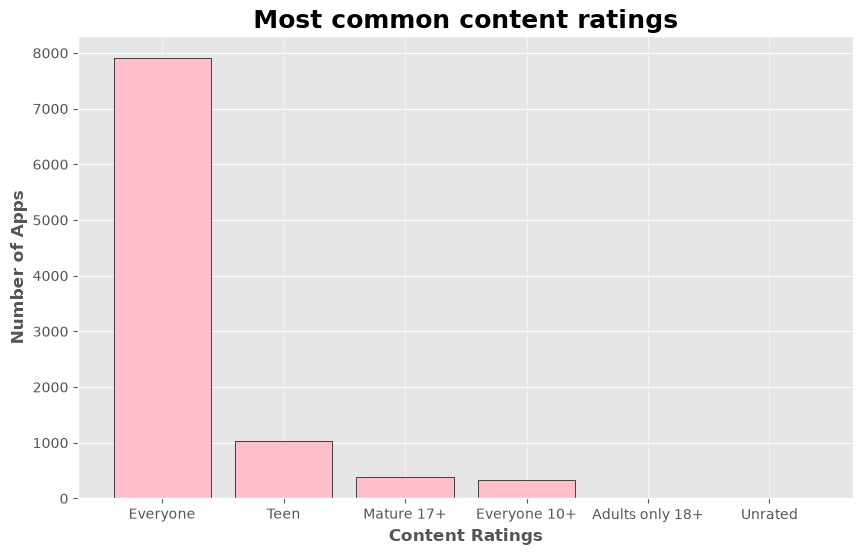

In [38]:
content_ratings = df['Content Rating'].value_counts()

plt.figure(figsize = (10,6))
plt.bar(content_ratings.index,content_ratings.values,color = 'pink',edgecolor = 'black')
# plt.xlim(3.8,4.5)
plt.grid(axis='x',alpha =0.5)
plt.xlabel('Content Ratings', fontweight = 'bold')
plt.ylabel('Number of Apps',fontweight = 'bold')
plt.title('Most common content ratings',fontsize=18,
          fontweight='bold',color='black')
plt.show()

* Play store is almost entirely loaded with apps whose content is suitable for everyone. The Adult, 18+, unrated content are almost negligible. There are also certain apps which are suitable for kids who are 10 to 17 year old.

---

### Correlation between numerical columns of the data :

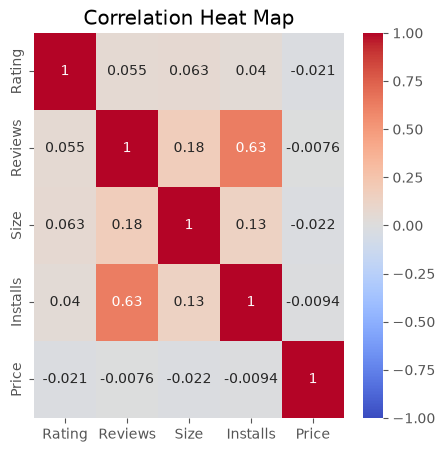

In [39]:
plt.figure(figsize = (5,5))
numeric_columns = df.select_dtypes(include = 'number')
sns.heatmap(numeric_columns.corr(),
           annot = True,
           cmap = 'coolwarm',vmin=-1,
            vmax=1)
plt.title('Correlation Heat Map')
plt.show()

* This heat map show that the numerical columns are not correlated. We can find Reviews and Installs with a strong correlation. It is a strange insight that reviews and size of the app are more dependent than price and installs.

---

### Outliers of numerical data :

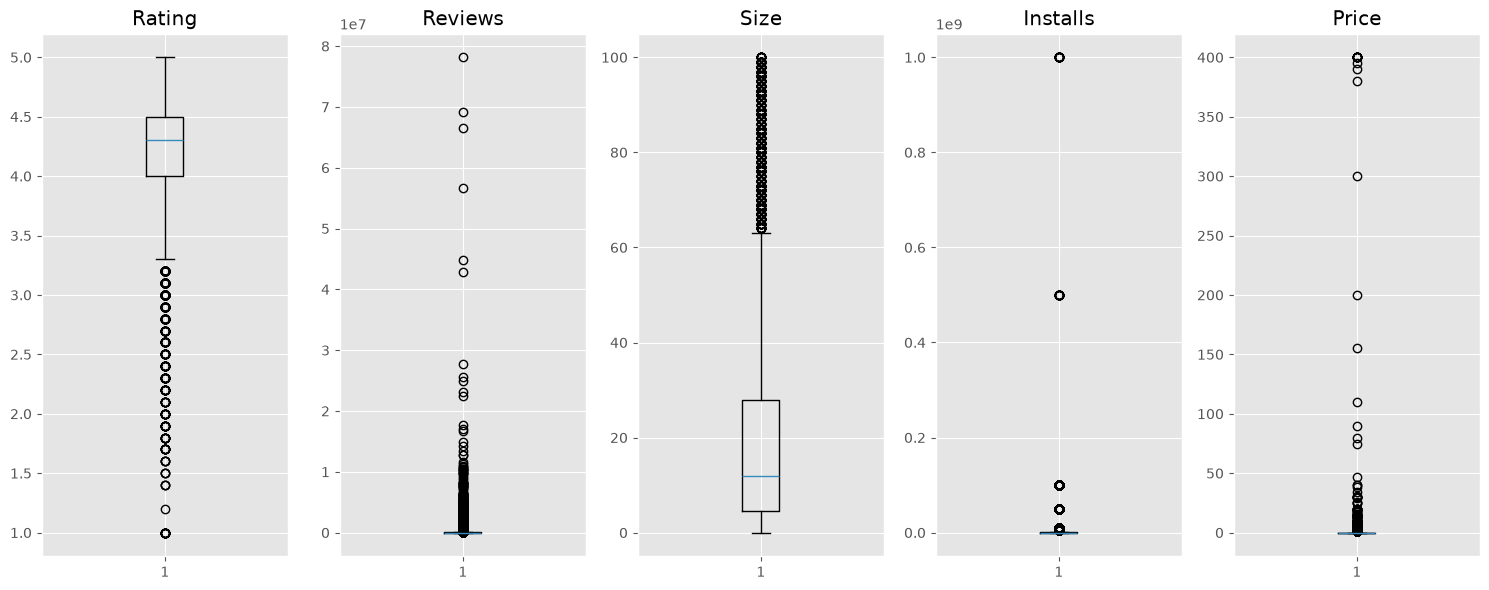

In [40]:
fig, axes = plt.subplots(1, 5, figsize=(15, 6))

for i, col in enumerate(numeric_columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

* we can observe that size and rating are the only numerical columns with less deviated data.

## Key Insights

The Google Play Store is dominated by free applications, accounting for more than 90% of all apps, indicating that the freemium business model is the industry's preferred strategy. The Family category contains the highest number of applications, while Games generate the largest number of installs, making them the most successful category in terms of user reach. Most applications receive ratings between 3.5 and 4.5 stars, suggesting that the majority of apps provide a satisfactory user experience. The analysis also shows a positive relationship between ratings, reviews, and installs, implying that well-rated applications generally attract more user engagement and downloads. Additionally, most apps are smaller than 40 MB, highlighting developers' preference for lightweight applications that are easier to download and use on mobile devices.

## Business Recommendations

Developers should prioritize building high-quality free applications with optional premium features or in-app purchases, since free apps dominate the market and attract the largest user base. Businesses targeting maximum reach should consider investing in Game and Family categories, as these consistently show high popularity and download volumes. Maintaining a rating above 4.0 stars should be a key objective because higher-rated apps tend to receive greater visibility and user engagement. Keeping application sizes small can further improve adoption, particularly for users with limited storage or slower internet connections. Finally, paid applications should offer clear and unique value, as increasing prices appear to be associated with lower download counts, making competitive pricing an important factor for market success